In [ ]:
from valdpy import ValdAuth, DynamoAPI
from valdpy.utils import read_credentials

%load_ext autoreload
%autoreload 2

# Dynamo API Example

This example demonstrates how to use the VALDPY package to access Dynamo (jump/power) test data.

In [ ]:
# Read credentials from file
creds = read_credentials('vald_api_cred.txt')

client_id = creds['client_id']
client_secret = creds['client_secret']
tenant_id = creds['tenant_id']

print(f"Client ID: {client_id[:10]}...")
print(f"Tenant ID: {tenant_id}")

Client ID: 
Client Secret: 
Tenant ID: 


## Step 1: Authentication

In [ ]:
auth = ValdAuth(client_id, client_secret, tenant_id=tenant_id, region='USA')

### Get OAuth Access Token

In [ ]:
token = auth.get_token()
print(f"Token obtained: {token[:20]}...")

### Optional: Get Tenant Information

In [ ]:
all_tenants = auth.get_all_tenants()
print(f"Found {len(all_tenants)} tenant(s)")

In [ ]:
# Get tenant info
tenant_info = auth.get_tenant_info()
print(f"Tenant Name: {tenant_info.get('name')}")
print(f"Tenant ID: {tenant_info.get('id')}")

## Step 2: Get Categories and Groups

In [ ]:
categories_df = auth.get_tenant_categories()
print(categories_df[['name', 'id']].to_string(index=False))

,id,syncId,name
0,306f33af-2939-480b-bbd7-2ce643c888f0,None,Uncategorised
1,3a32a047-1292-49f1-a8aa-8f830ea58ac8,None,Position
2,1fdaf750-970a-4047-badc-945e6e6994cf,None,Team
3,2828d5d2-ce26-4297-b4c1-a16039889a86,None,Sport


In [ ]:
groups_df = auth.get_tenant_groups()
print(f"Found {len(groups_df)} group(s)")
print(groups_df[['name', 'id']].head(10).to_string(index=False))

,id,name,categoryId,syncId
0,286167da-0a3c-4da9-9b09-316ba9f6e089,Acro and Tumbling,1fdaf750-970a-4047-badc-945e6e6994cf,None
1,61694101-179d-483f-a8c7-8c5632362760,Acro and Tumbling,2828d5d2-ce26-4297-b4c1-a16039889a86,None
2,20588edf-7394-489c-a502-1f0c10c25db8,Baseball,2828d5d2-ce26-4297-b4c1-a16039889a86,None
3,f26a6a9c-7232-4d01-a214-b3f8584ba293,Baseball,1fdaf750-970a-4047-badc-945e6e6994cf,None
4,fa4489a4-4a0e-4003-869d-3a7565e82fe4,Football,2828d5d2-ce26-4297-b4c1-a16039889a86,None


## Step 3: Get Profiles

In [ ]:
group_name = 'Research'
category_name = 'Team'

try:
    profiles_df = auth.get_group_profiles(group_name=group_name, category_name=category_name)
    print(f"Found {len(profiles_df)} profile(s)")
    print(profiles_df[['firstName', 'lastName', 'profileId']].head(10).to_string(index=False))
except Exception as e:
    print(f"Error: {e}")

## Step 4: Initialize Dynamo API

In [ ]:
dynamo = DynamoAPI(tenant_id=auth.tenant_id, header=auth.header, region='USA')

### Get Tests Between Dates

Query Dynamo tests within a date range (max 180 days).

In [ ]:
start_date = '01/01/2025'
end_date = '31/01/2025'

tests_df = dynamo.get_tests(start_date, end_date)

if tests_df is not None:
    print(f"Found {len(tests_df)} test(s)")
    print(tests_df[['testId', 'profileId']].head())
else:
    print("No tests found in date range")

,id,athleteId,teamId,testCategory,bodyRegion,movement,position,customPosition,laterality,attachments,leftAttachment,rightAttachment,startTimeUTC,durationSeconds,hardwareInfo,softwareInfo,analysisInfo,analysedDateUTC,asymmetries,ratios
0,f89aa139-33de-472d-aeda-a05194f3f86c,a1eb1996-8091-439c-8a14-cf5bd9d6041e,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Knee,Extension,Seated,,RightThenLeft,LeftPalmPadRightCurvedPad,TensionLink,TensionLink,2026-01-21T17:54:06.704846Z,490.157765,DynaMo-04152;DYNO-220620-FW1R6-HW1R2,"iOS;iPad12,1;18.6.2;1.10.1;#116",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2026-01-21T18:02:22.026258Z,"[{'movement': 'Extension', 'valuePercentage': ...",[]
1,b1617a1b-455d-4dfe-849c-fbecee5aa9e1,491bb35b-335a-4b82-b048-dc6ae9fc4d46,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Knee,Extension,Seated,,LeftThenRight,LeftPalmPadRightCurvedPad,None,None,2026-01-20T16:32:48.367091Z,659.329245,DynaMo-00460;DYNO-220620-FW1R6-HW1R2,"iOS;iPhone17,1;26.2;1.10.1;#116",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2026-01-20T16:43:49.214555Z,"[{'movement': 'Extension', 'valuePercentage': ...",[]
2,400996f7-cbc9-4579-b0b3-e6290315cf99,4ea97160-ea82-4822-abb9-0c0a84c68981,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Knee,Extension,Seated,,RightThenLeft,LeftPalmPadRightCurvedPad,TensionLink,TensionLink,2026-01-15T16:36:08.447224Z,106.977787,DynaMo-00460;DYNO-220620-FW1R6-HW1R2,"iOS;iPad12,1;18.6.2;1.10.1;#116",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2026-01-15T16:38:43.72289Z,"[{'movement': 'Extension', 'valuePercentage': ...",[]
3,1f9ebab5-b23e-4b9d-affd-8e8660957b3f,ba150b5b-5815-4302-9c00-e0bbbc0b5c3c,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Knee,Extension,Seated,,LeftThenRight,LeftPalmPadRightCurvedPad,TensionLink,TensionLink,2026-01-15T16:32:23.352006Z,135.839037,DynaMo-00460;DYNO-220620-FW1R6-HW1R2,"iOS;iPad12,1;18.6.2;1.10.1;#116",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2026-01-15T16:35:17.047118Z,"[{'movement': 'Extension', 'valuePercentage': 9}]",[]
4,80f7f2f4-b3af-4ae3-8040-9001557e2982,89ffbe31-7c52-4d85-b704-6907c989cbb7,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Knee,Extension,Seated,,RightThenLeft,LeftPalmPadRightCurvedPad,TensionLink,TensionLink,2026-01-15T16:24:40.786077Z,171.870098,DynaMo-00460;DYNO-220620-FW1R6-HW1R2,"iOS;iPad12,1;18.6.2;1.10.1;#116",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2026-01-15T16:28:31.386707Z,"[{'movement': 'Extension', 'valuePercentage': ...",[]


In [ ]:
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    results_df = dynamo.get_test_results(test_id)
    
    if results_df is not None:
        print(f"Test Results Shape: {results_df.shape}")
        print(results_df.head())
    else:
        print("No results found")
else:
    print("No tests available")

,id,athleteId,teamId,testCategory,bodyRegion,movement,position,customPosition,laterality,attachments,leftAttachment,rightAttachment,startTimeUTC,durationSeconds,hardwareInfo,softwareInfo,analysisInfo,analysedDateUTC,asymmetries,ratios
0,5132df25-916c-4750-82af-8d012b964f04,3857c117-8866-4591-98dc-078b2a9a55aa,61476d2d-917a-4b2e-b2f6-e43346d2cb66,Strength,Hand,GripSqueeze,p90DegreesElbowFlexion,,LeftSide,LeftPalmPadRightCurvedPad,GripOuter,GripInner,2025-10-20T16:08:15.903631Z,30.939766,DynaMo-04075;DYNO-220620-FW1R6-HW1R2,"iOS;iPad12,1;18.6.2;1.9.9;#114",Dynamo.Analysis;1.0.0.0;225Hz;30N;Auto ROM Det...,2025-10-20T16:08:46.843397Z,[],[]


### Step 2 - Get individual test results
Using "get_test_results()", a test ID is used to pull the results for each rep within a denoted test. The resulting dataframe contains a row for each result from each rep.
Some what obsolete a get_test() returns test results as well.

In [27]:
testID = dynamo.tests_df.loc[0,'id']
dynamo.get_test_results(testID)
dynamo.tests_df.head()

,id,testId,movement,limb,rep,startOffsetSeconds,durationSeconds,maxForceNewtons,impulseNewtonSeconds,rateOfForceDevelopmentNewtonsPerSecond,...,netForceAt100msNewtons,netForceAt150msNewtons,netForceAt200msNewtons,netImpulseAt100msNewtonSeconds,netImpulseAt150msNewtonSeconds,netImpulseAt200msNewtonSeconds,timeTo80PercentPeakForceSeconds,rateOfForceDevelopment150msNewtonsPerSecond,rateOfForceDevelopment200msNewtonsPerSecond,rateOfForceDevelopment250msNewtonsPerSecond
0,9e181c9e-4a8f-4971-a5de-921b446ae650,5132df25-916c-4750-82af-8d012b964f04,GripSqueeze,LeftSide,1,5.186148,3.679632,611.5,1850.912224,2618.087896,...,None,None,None,None,None,None,None,None,None,None
1,fb5f3e88-bc9a-47d7-aa7a-efddb735c41c,5132df25-916c-4750-82af-8d012b964f04,GripSqueeze,LeftSide,2,20.780144,3.679632,527.4,1661.853798,3161.076977,...,None,None,None,None,None,None,None,None,None,None


### Step 3 - Get the force trace for a given test
Using "get_force_trace()" will return the force trace in a dataframe for a given test ID.

In [36]:
dynamo.get_force_trace(testID)
dynamo.raw['forceTrace'].head()

,timeSeconds,forceNewtons
0,0.000000,20.3
1,0.004444,21.4
2,0.008888,22.5
3,0.013332,22.5
4,0.017776,21.9


<Axes: title={'center': 'DynamoForce Trace'}, xlabel='Time (s)', ylabel='Force (N)'>

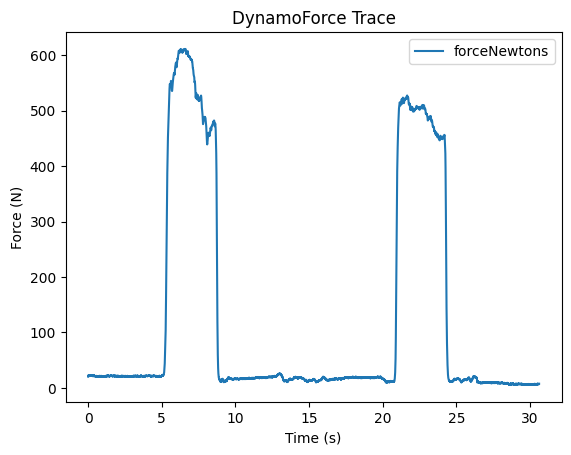

In [39]:
# To access raw force trace within API call response
dynamo.raw['forceTrace'].plot(x='timeSeconds',y='forceNewtons',title='DynamoForce Trace',xlabel='Time (s)',ylabel='Force (N)')